# 02 Data Visualization

This notebook applies **t-SNE** (t-distributed Stochastic Neighbor Embedding) to the preprocessed student dataset to visualize high-dimensional data in 2D and 3D. Points are colored by the Target class (Dropout / Enrolled / Graduate) to reveal clustering patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Load preprocessed data (standardized + one-hot encoded)
df = pd.read_csv('../data/data_preprocessed.csv')

# Separate features and target
target = df['Target']
target_encoded = df['Target_encoded']
X = df.drop(columns=['Target', 'Target_encoded'])

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:\n{target.value_counts()}')

Feature matrix shape: (4424, 238)
Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## 1. t-SNE 2D Visualization

We reduce the high-dimensional feature space to 2 dimensions using t-SNE. Key parameters:
- `perplexity=30`: balances local vs. global structure (default, works well for datasets of this size)
- `random_state=42`: for reproducibility
- `max_iter=1000`: sufficient iterations for convergence

In [2]:
# Run t-SNE for 2D embedding
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_2d = tsne_2d.fit_transform(X)

print(f't-SNE 2D embedding shape: {X_2d.shape}')
print(f'KL divergence: {tsne_2d.kl_divergence_:.4f}')

/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul

t-SNE 2D embedding shape: (4424, 2)
KL divergence: 1.5826


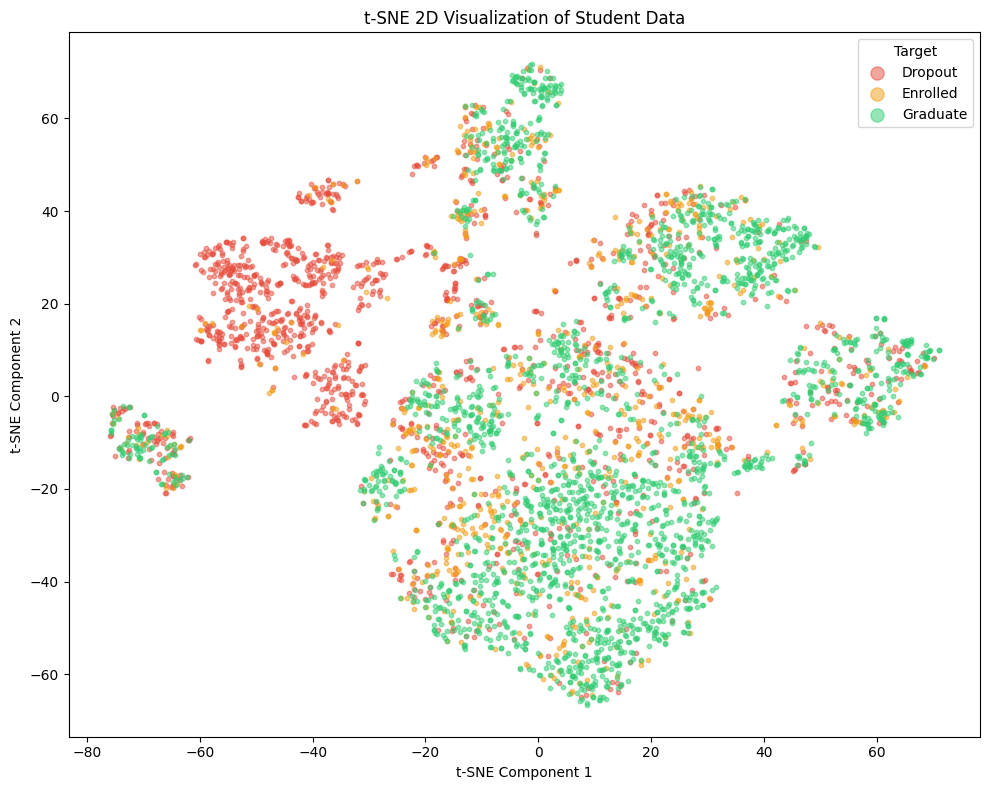

In [3]:
# 2D scatter plot colored by Target class
fig, ax = plt.subplots(figsize=(10, 8))

colors = {'Dropout': '#e74c3c', 'Enrolled': '#f39c12', 'Graduate': '#2ecc71'}
for label in ['Dropout', 'Enrolled', 'Graduate']:
    mask = target == label
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors[label], label=label, alpha=0.5, s=10)

ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_title('t-SNE 2D Visualization of Student Data')
ax.legend(title='Target', markerscale=3)
plt.tight_layout()
plt.savefig('../outputs/tsne_2d.png', dpi=150)
plt.show()

## 2. t-SNE 3D Visualization

A 3D embedding can sometimes reveal additional structure not visible in 2D.

In [4]:
# Run t-SNE for 3D embedding
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42, max_iter=1000)
X_3d = tsne_3d.fit_transform(X)

print(f't-SNE 3D embedding shape: {X_3d.shape}')
print(f'KL divergence: {tsne_3d.kl_divergence_:.4f}')

/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul

t-SNE 3D embedding shape: (4424, 3)
KL divergence: 1.3984


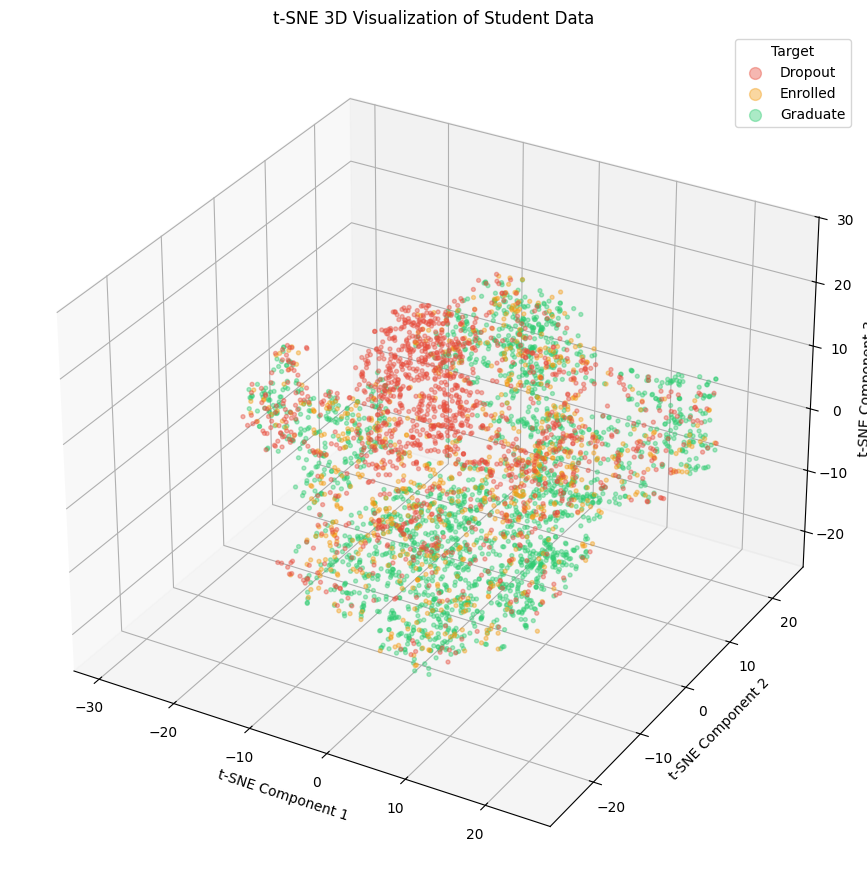

In [5]:
# 3D scatter plot colored by Target class
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

for label in ['Dropout', 'Enrolled', 'Graduate']:
    mask = target == label
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
               c=colors[label], label=label, alpha=0.4, s=8)

ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')
ax.set_title('t-SNE 3D Visualization of Student Data')
ax.legend(title='Target', markerscale=3)
plt.tight_layout()
plt.savefig('../outputs/tsne_3d.png', dpi=150)
plt.show()

## 3. Effect of Perplexity

Perplexity controls how t-SNE balances local vs. global structure. We compare multiple values to check robustness of the observed patterns.

/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul

/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul

/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul

/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sea/machine-learning/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul

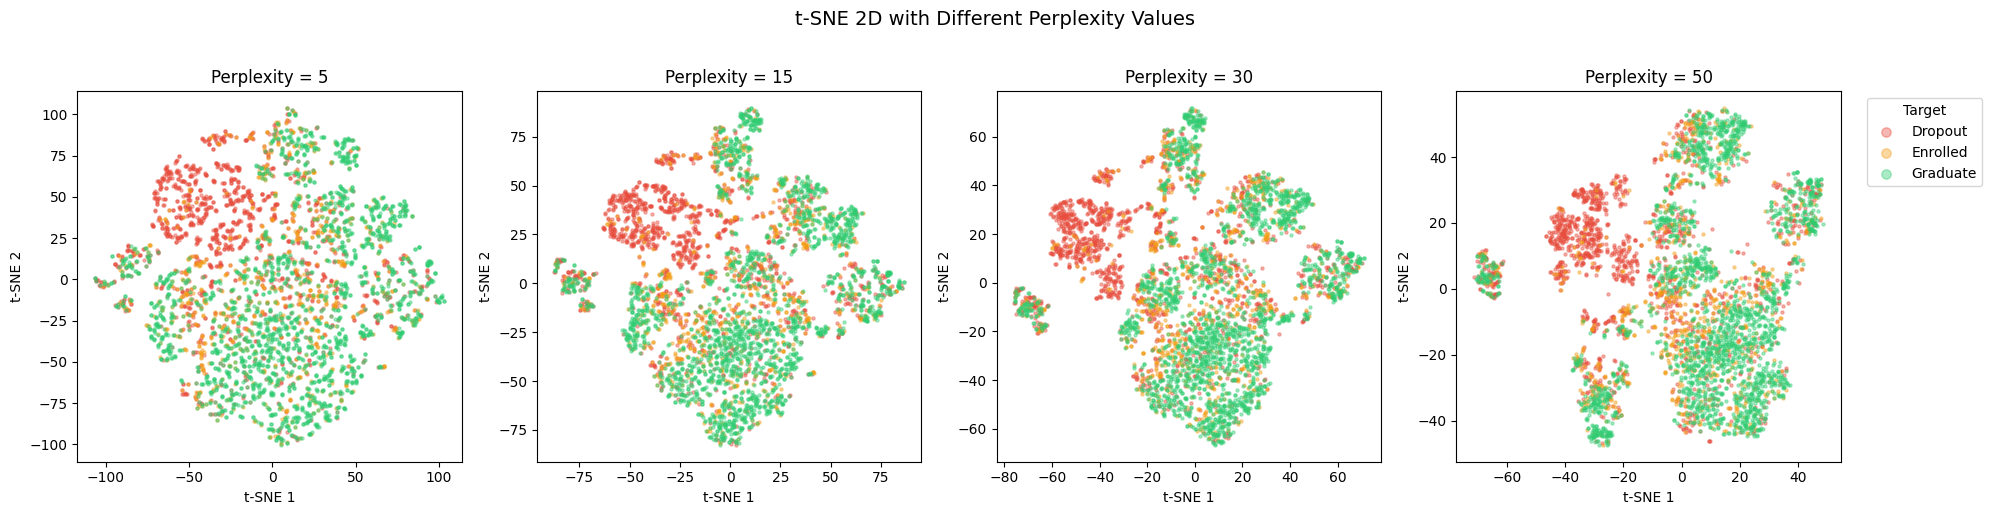

In [6]:
# Compare different perplexity values
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
    X_emb = tsne.fit_transform(X)
    for label in ['Dropout', 'Enrolled', 'Graduate']:
        mask = target == label
        ax.scatter(X_emb[mask, 0], X_emb[mask, 1],
                   c=colors[label], label=label, alpha=0.4, s=5)
    ax.set_title(f'Perplexity = {perp}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

axes[-1].legend(title='Target', markerscale=3, bbox_to_anchor=(1.05, 1))
plt.suptitle('t-SNE 2D with Different Perplexity Values', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/tsne_perplexity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Analysis

### Observations

1. **Cluster separation**: Dropout students (red) tend to cluster on the **left side** of the 2D embedding, while Graduate students (green) dominate the **right and bottom** regions. This suggests meaningful differences in their feature profiles.

2. **Overlap regions**: Enrolled students (orange) are **heavily mixed** with both Dropout and Graduate clusters, particularly in the central region. This makes sense — enrolled students haven't reached a final outcome yet and may share characteristics with either group. Predicting the Enrolled class will likely be the hardest task.

3. **Sub-clusters**: Multiple small, tight clusters are visible (especially in the upper-right for Graduates and upper-left for Dropouts). These likely correspond to different **Course** or **Application mode** categories from the one-hot encoding, grouping students with similar academic programs.

4. **Perplexity sensitivity**: The class separation pattern is **consistent across all perplexity values** (5, 15, 30, 50), confirming that the observed structure is genuine and not an artifact. Lower perplexity (5) produces a more diffuse, spread-out embedding; higher values (30, 50) reveal more distinct, tightly grouped sub-clusters as the algorithm captures broader neighborhood structure.

### Implications for Modeling

- The partial separability between Dropout and Graduate classes suggests that **classification models should achieve reasonable accuracy** for these two classes.
- The Enrolled class overlap indicates it will be the most challenging to predict — consider whether to treat this as a **binary problem** (Dropout vs. Graduate) in addition to the 3-class task.
- The presence of sub-clusters suggests that **Course** and other categorical features play a strong role in defining student groups.